In [37]:
import pandas as pd
activityLogs = pd.read_csv(r'C:\Users\LENOVO\Downloads\ActivityLogs_Regenerated.csv')
subscription = pd.read_csv(r'C:\Users\LENOVO\Downloads\Subscription_Regenerated.csv')
users = pd.read_csv(r'C:\Users\LENOVO\Documents\Internship\Users.csv')

In [1]:
#Merge Login Frequency Counts with Subscription Data

In [40]:
login_counts = (
    activityLogs[activityLogs['Action'] == 'Login']
    .groupby('UserID')
    .size()
    .reset_index(name='Num_Logins')
)

print(login_counts.head())

   UserID  Num_Logins
0       1           5
1       2           3
2       3           2
3       4           4
4       5           3


In [41]:
user_data = login_counts.merge(
    subscription,
    on='UserID',
    how='left'
)

print(user_data.head())

   UserID  Num_Logins PlanType  Renewed
0       1           5  Premium        1
1       2           3     Free        1
2       3           2     Free        1
3       4           4     Free        0
4       5           3     Free        0


In [42]:
print(activityLogs['UserID'].nunique())
print(activityLogs['UserID'].head(20))

5000
0     1833
1     2586
2     3648
3       80
4     4710
5     2224
6     2570
7     1773
8     4519
9     1124
10    3812
11    3475
12    2624
13    1404
14    2579
15     332
16    4749
17    3609
18     740
19    4607
Name: UserID, dtype: int64


In [46]:
users = users.rename(columns={'UserID': 'ID'})

In [47]:
print(users['ID'].head())

0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64


In [48]:
print(users['ID'].head())
print(users['ID'].nunique())

0    1
1    2
2    3
3    4
4    5
Name: ID, dtype: int64
5000


In [ ]:
#Generate Correlation Heatmap for 'Logins' vs 'Renewal'

In [49]:
corr_matrix = user_data[['Num_Logins', 'Renewed']].corr()

print(corr_matrix)

            Num_Logins   Renewed
Num_Logins    1.000000  0.005162
Renewed       0.005162  1.000000


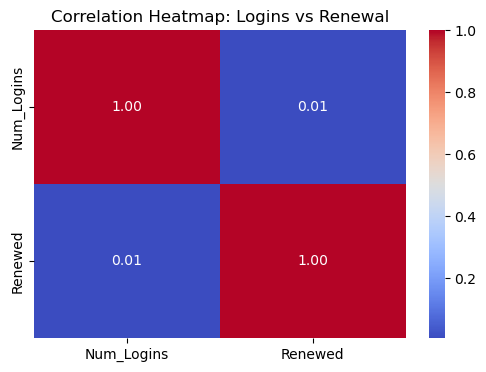

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap: Logins vs Renewal')
plt.show()


In [52]:
#Identify statistically significant usage patterns

#Do Renewed Users Log In More Often?

from scipy.stats import ttest_ind

renewed = user_data[user_data['Renewed'] == 1]['Num_Logins']
not_renewed = user_data[user_data['Renewed'] == 0]['Num_Logins']

t_stat, p_value = ttest_ind(
    renewed,
    not_renewed,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 0.35367008142730455
P-value: 0.7236046160937782


In [53]:
if p_value < 0.05:
    print("Significant difference found")
else:
    print("No significant difference found")

No significant difference found


In [54]:
#Does Symptom Checker Usage Affect Retention?
symptom_usage = (
    activityLogs[activityLogs['Action'] == 'Symptom_Check']
    .groupby('UserID')
    .size()
    .reset_index(name='Symptom_Usage')
)

In [55]:
symptom_usage = symptom_usage.merge(
    subscription[['UserID','Renewed']],
    on='UserID'
)

In [56]:
renewed = symptom_usage[
    symptom_usage['Renewed']==1
]['Symptom_Usage']

not_renewed = symptom_usage[
    symptom_usage['Renewed']==0
]['Symptom_Usage']

t_stat, p_value = ttest_ind(
    renewed,
    not_renewed,
    equal_var=False
)

print(p_value)

0.1609280815110691


In [57]:
#Session duration vs renewal

In [58]:
sessions['session_start'] = pd.to_datetime(
    sessions['session_start']
)

sessions['session_end'] = pd.to_datetime(
    sessions['session_end']
)

sessions['SessionMinutes'] = (
    sessions['session_end']
    - sessions['session_start']
).dt.total_seconds()/60

In [59]:
session_avg = (
    sessions.groupby('user_id')
    ['SessionMinutes']
    .mean()
    .reset_index()
)

In [60]:
print(session_avg)

  user_id  SessionMinutes
0    U001            27.0
1    U002            30.5
2    U003            32.5
3    U004            43.0
4    U005            42.0
